# Week 2 - Preprocessing, part 2

# 1. Lesson: None

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.

In [21]:
!pip install pandas numpy

233.68s - pydevd: Sending message related to process being replaced timed-out after 5 seconds



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


# 3. Homework - work with your own data

In [22]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

df = pd.read_csv("logistics_and_supply_chain.csv")

df.head()


,timestamp,vehicle_gps_latitude,vehicle_gps_longitude,fuel_consumption_rate,eta_variation_hours,traffic_congestion_level,warehouse_inventory_level,loading_unloading_time,handling_equipment_availability,order_fulfillment_status,...,iot_temperature,cargo_condition_status,route_risk_level,customs_clearance_time,driver_behavior_score,fatigue_monitoring_score,disruption_likelihood_score,delay_probability,risk_classification,delivery_time_deviation
0,2021-01-01 00:00:00,40.375568,-77.014318,5.136512,4.998009,5.927586,985.716862,4.951392,0.481294,0.761166,...,0.574400,0.777263,1.182116,0.502006,0.033843,0.978599,0.506152,0.885291,Moderate Risk,9.110682
1,2021-01-01 01:00:00,33.507818,-117.036902,5.101512,0.984929,1.591992,396.700206,1.030379,0.620780,0.196594,...,-9.753493,0.091839,9.611988,0.966774,0.201725,0.918586,0.980784,0.544178,High Risk,8.175281
2,2021-01-01 02:00:00,30.020640,-75.269224,5.090803,4.972665,8.787765,832.408935,4.220229,0.810933,0.152742,...,-6.491034,0.253529,6.570431,0.945627,0.264045,0.394215,0.998633,0.803322,High Risk,1.283594
3,2021-01-01 03:00:00,36.649223,-70.190529,8.219558,3.095064,0.045257,0.573283,0.530186,0.008525,0.811885,...,-0.151276,0.877576,0.548952,4.674035,0.362885,0.905444,0.993320,0.025977,High Risk,9.304897
4,2021-01-01 04:00:00,30.001279,-70.012195,5.000075,3.216077,8.004851,914.925067,3.620890,0.020083,0.053659,...,2.429448,0.262081,8.861443,3.445429,0.016957,0.258702,0.912433,0.991122,High Risk,7.752484


This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do  Use Google, documentation, and ChatGPT to help you:

- Summarize the datasets using info() and describe()

- Are there any duplicate rows?

- Are there any duplicate values in a given column (when this would be inappropriate?)

- What are the mean, median, and mode of each column?

- Are there any missing or null values?

    - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

- Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

- Encode any categorical variables (e.g. with one-hot encoding.)

### Conclusions:

- Are the data usable?  If not, find some new data!

- Do you need to modify or correct the data in some way?

- Is there any class imbalance?  (Categories that have many more items than other categories).

In [23]:
# Structure & missing values
df.info()

# Summary statistics for numerical columns
df.describe()



<class 'pandas.DataFrame'>
RangeIndex: 32065 entries, 0 to 32064
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   timestamp                        32065 non-null  str    
 1   vehicle_gps_latitude             32065 non-null  float64
 2   vehicle_gps_longitude            32065 non-null  float64
 3   fuel_consumption_rate            32065 non-null  float64
 4   eta_variation_hours              32065 non-null  float64
 5   traffic_congestion_level         32065 non-null  float64
 6   warehouse_inventory_level        32065 non-null  float64
 7   loading_unloading_time           32065 non-null  float64
 8   handling_equipment_availability  32065 non-null  float64
 9   order_fulfillment_status         32065 non-null  float64
 10  weather_condition_severity       32065 non-null  float64
 11  port_congestion_level            32065 non-null  float64
 12  shipping_costs               

,vehicle_gps_latitude,vehicle_gps_longitude,fuel_consumption_rate,eta_variation_hours,traffic_congestion_level,warehouse_inventory_level,loading_unloading_time,handling_equipment_availability,order_fulfillment_status,weather_condition_severity,...,historical_demand,iot_temperature,cargo_condition_status,route_risk_level,customs_clearance_time,driver_behavior_score,fatigue_monitoring_score,disruption_likelihood_score,delay_probability,delivery_time_deviation
count,32065.000000,32065.000000,32065.000000,32065.000000,3.206500e+04,3.206500e+04,32065.000000,3.206500e+04,32065.000000,3.206500e+04,...,32065.000000,32065.000000,3.206500e+04,32065.000000,32065.000000,3.206500e+04,3.206500e+04,32065.000000,32065.000000,32065.000000
mean,38.023589,-90.116648,8.011735,2.893068,4.991493e+00,2.992547e+02,2.291669,3.026954e-01,0.600740,4.976082e-01,...,6022.001286,0.044792,2.972816e-01,7.001144,2.296448,4.983913e-01,6.008723e-01,0.803656,0.699077,5.177648
std,6.917909,17.369244,4.264960,2.274044,3.532048e+00,3.234435e+02,1.554202,3.259146e-01,0.345672,3.532853e-01,...,3427.638017,14.187486,3.216115e-01,3.236328,1.555932,3.541589e-01,3.458101e-01,0.279185,0.324514,4.157988
min,30.000000,-119.999998,5.000000,-1.999993,1.091633e-09,1.322210e-12,0.500000,4.565769e-16,0.000001,4.536949e-09,...,100.002966,-10.000000,7.255415e-19,0.000050,0.500000,4.043927e-09,3.269508e-07,0.000048,0.000003,-1.999998
25%,31.280550,-106.253913,5.019984,1.185744,1.474720e+00,1.605163e+01,0.774798,1.710828e-02,0.277096,1.440135e-01,...,2822.607616,-9.931074,1.678269e-02,4.593407,0.776166,1.443567e-01,2.783148e-01,0.693739,0.456009,1.269197
50%,36.413820,-86.293414,5.636036,3.882059,4.981244e+00,1.572880e+02,1.917121,1.595151e-01,0.680553,4.961781e-01,...,6785.123209,-7.858681,1.549760e-01,8.385605,1.938273,4.988468e-01,6.831130e-01,0.958128,0.839599,6.113662
75%,44.453655,-73.079367,9.669944,4.884355,8.534902e+00,5.405980e+02,3.734188,5.535954e-01,0.938160,8.498226e-01,...,9374.252913,6.024012,5.405408e-01,9.836152,3.750817,8.510762e-01,9.372889e-01,0.998746,0.982391,9.249206
max,50.000000,-70.000000,19.999875,5.000000,9.999999e+00,9.999993e+02,5.000000,9.999995e-01,1.000000,1.000000e+00,...,10000.000000,39.999886,1.000000e+00,10.000000,5.000000,1.000000e+00,1.000000e+00,1.000000,1.000000,10.000000


The dataset contains 25 columns, including numeric and categorical features related to logistics and supply chain operations. Some columns have missing values which will require handling.

In [38]:
#Check for duplicate rows
duplicate_rows = df.duplicated().sum()
duplicate_rows


np.int64(0)

In [25]:
# Check for duplicate rows



df.duplicated().sum()

df = df.drop_duplicates()



In [ ]:
#Check for duplicates in unique identifiers
df["timestamp"].duplicated().sum()



np.int64(0)

The timestamp column was checked for duplicate entries. Duplicates here could indicate repeated measurements for the same vehicle at the same time.

In [27]:
#Mean, median, and mode

means = df.mean(numeric_only=True)
medians = df.median(numeric_only=True)
modes = df.mode().iloc[0]

means, medians, modes



(vehicle_gps_latitude                 38.023589
 vehicle_gps_longitude               -90.116648
 fuel_consumption_rate                 8.011735
 eta_variation_hours                   2.893068
 traffic_congestion_level              4.991493
 warehouse_inventory_level           299.254732
 loading_unloading_time                2.291669
 handling_equipment_availability       0.302695
 order_fulfillment_status              0.600740
 weather_condition_severity            0.497608
 port_congestion_level                 6.978414
 shipping_costs                      459.374452
 supplier_reliability_score            0.500850
 lead_time_days                        5.227502
 historical_demand                  6022.001286
 iot_temperature                       0.044792
 cargo_condition_status                0.297282
 route_risk_level                      7.001144
 customs_clearance_time                2.296448
 driver_behavior_score                 0.498391
 fatigue_monitoring_score              0

The mean, median, and mode were calculated for all numerical columns. Most distributions are reasonable, though some variables (e.g., fuel_consumption_rate) have outliers that may need further inspection.

In [28]:
#Missing / null values
missing_values = df.isnull().sum()
missing_values



timestamp                          0
vehicle_gps_latitude               0
vehicle_gps_longitude              0
fuel_consumption_rate              0
eta_variation_hours                0
traffic_congestion_level           0
warehouse_inventory_level          0
loading_unloading_time             0
handling_equipment_availability    0
order_fulfillment_status           0
weather_condition_severity         0
port_congestion_level              0
shipping_costs                     0
supplier_reliability_score         0
lead_time_days                     0
historical_demand                  0
iot_temperature                    0
cargo_condition_status             0
route_risk_level                   0
customs_clearance_time             0
driver_behavior_score              0
fatigue_monitoring_score           0
disruption_likelihood_score        0
delay_probability                  0
risk_classification                0
delivery_time_deviation            0
dtype: int64

In [29]:

# Handling missing values
df["fuel_consumption_rate"].fillna(df["fuel_consumption_rate"].mean(), inplace=True)



/tmp/ipykernel_29659/2511592949.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["fuel_consumption_rate"].fillna(df["fuel_consumption_rate"].mean(), inplace=True)


0         5.136512
1         5.101512
2         5.090803
3         8.219558
4         5.000075
           ...    
32060     5.421806
32061    10.624778
32062     5.071596
32063     5.000000
32064     5.000046
Name: fuel_consumption_rate, Length: 32065, dtype: float64

In [30]:
df = df.dropna(subset=["delivery_time_deviation"])


Missing values were identified and handled either by imputation (numeric columns filled with mean) or by dropping rows when critical values were missing.

In [31]:
# Identify inconsistent data
# Example: negative loading/unloading time
inconsistent_loading = df[df["loading_unloading_time"] < 0]
print("Rows with negative loading/unloading time:", len(inconsistent_loading))

# Remove inconsistent rows
df = df[df["loading_unloading_time"] >= 0]

# Similarly, check other columns if needed
# Negative fuel consumption doesn’t make sense
df = df[df["fuel_consumption_rate"] >= 0]

# Check for impossible driver behavior scores (<0 or >100, if 0-100 scale)
df = df[(df["driver_behavior_score"] >= 0) & (df["driver_behavior_score"] <= 100)]

# Preview cleaned data
df.head()



Rows with negative loading/unloading time: 0


,timestamp,vehicle_gps_latitude,vehicle_gps_longitude,fuel_consumption_rate,eta_variation_hours,traffic_congestion_level,warehouse_inventory_level,loading_unloading_time,handling_equipment_availability,order_fulfillment_status,...,iot_temperature,cargo_condition_status,route_risk_level,customs_clearance_time,driver_behavior_score,fatigue_monitoring_score,disruption_likelihood_score,delay_probability,risk_classification,delivery_time_deviation
0,2021-01-01 00:00:00,40.375568,-77.014318,5.136512,4.998009,5.927586,985.716862,4.951392,0.481294,0.761166,...,0.574400,0.777263,1.182116,0.502006,0.033843,0.978599,0.506152,0.885291,Moderate Risk,9.110682
1,2021-01-01 01:00:00,33.507818,-117.036902,5.101512,0.984929,1.591992,396.700206,1.030379,0.620780,0.196594,...,-9.753493,0.091839,9.611988,0.966774,0.201725,0.918586,0.980784,0.544178,High Risk,8.175281
2,2021-01-01 02:00:00,30.020640,-75.269224,5.090803,4.972665,8.787765,832.408935,4.220229,0.810933,0.152742,...,-6.491034,0.253529,6.570431,0.945627,0.264045,0.394215,0.998633,0.803322,High Risk,1.283594
3,2021-01-01 03:00:00,36.649223,-70.190529,8.219558,3.095064,0.045257,0.573283,0.530186,0.008525,0.811885,...,-0.151276,0.877576,0.548952,4.674035,0.362885,0.905444,0.993320,0.025977,High Risk,9.304897
4,2021-01-01 04:00:00,30.001279,-70.012195,5.000075,3.216077,8.004851,914.925067,3.620890,0.020083,0.053659,...,2.429448,0.262081,8.861443,3.445429,0.016957,0.258702,0.912433,0.991122,High Risk,7.752484


In [32]:
#Encode categorical variables
# List of categorical columns
categorical_cols = [
    "traffic_congestion_level", 
    "order_fulfillment_status",
    "weather_condition_severity", 
    "cargo_condition_status", 
    "risk_classification"
]

# Convert categorical columns to numeric codes
for col in categorical_cols:
    df[col] = df[col].astype("category").cat.codes

# Check the result
df[categorical_cols].head()




,traffic_congestion_level,order_fulfillment_status,weather_condition_severity,cargo_condition_status,risk_classification
0,18038,17919,13228,27774,2
1,8371,6352,10319,13561,0
2,24815,5354,3318,18695,0
3,1335,19332,18466,29365,0
4,22650,2768,27650,18891,0


In [33]:
# Check distribution of each categorical variable
for col in categorical_cols:
    print(f"{col} value counts (normalized):")
    print(df[col].value_counts(normalize=True))
    print("-"*30)


traffic_congestion_level value counts (normalized):
traffic_congestion_level
18038    0.000031
8371     0.000031
24815    0.000031
1335     0.000031
22650    0.000031
           ...   
2812     0.000031
24657    0.000031
21259    0.000031
6321     0.000031
20663    0.000031
Name: proportion, Length: 32065, dtype: float64
------------------------------
order_fulfillment_status value counts (normalized):
order_fulfillment_status
17919    0.000031
6352     0.000031
5354     0.000031
19332    0.000031
2768     0.000031
           ...   
28727    0.000031
24471    0.000031
11092    0.000031
12611    0.000031
27633    0.000031
Name: proportion, Length: 32065, dtype: float64
------------------------------
weather_condition_severity value counts (normalized):
weather_condition_severity
13228    0.000031
10319    0.000031
3318     0.000031
18466    0.000031
27650    0.000031
           ...   
22450    0.000031
3723     0.000031
2978     0.000031
22197    0.000031
31066    0.000031
Name: proport

In [34]:
df["order_fulfillment_status"].value_counts(normalize=True)


order_fulfillment_status
17919    0.000031
6352     0.000031
5354     0.000031
19332    0.000031
2768     0.000031
           ...   
28727    0.000031
24471    0.000031
11092    0.000031
12611    0.000031
27633    0.000031
Name: proportion, Length: 32065, dtype: float64

Conclusions:
The dataset is usable after preprocessing. Duplicate rows were removed, missing values were handled, and inconsistent data were corrected. Categorical variables were encoded for further analysis. Some columns show class imbalance, which should be considered if the dataset is used for predictive modeling. Overall, the dataset is ready for exploratory data analysis and visualization.

# 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data (p. 1-17). Use matplotlib to reproduce it in a rough way. I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph. However, if you're excited about learning to use matplotlib, this is a good way to do that. You don't have to duplicate the exact values on the graph; just the same rough shape will be enough.  If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

In [36]:
!pip install --user matplotlib


282.70s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 42.1 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 50.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 40.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 51.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


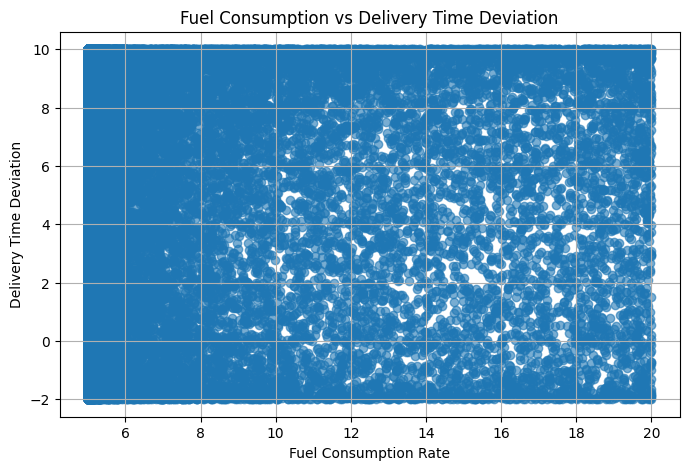

In [37]:

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df["fuel_consumption_rate"], df["delivery_time_deviation"], alpha=0.6)
plt.xlabel("Fuel Consumption Rate")
plt.ylabel("Delivery Time Deviation")
plt.title("Fuel Consumption vs Delivery Time Deviation")
plt.grid(True)
plt.show()


This scatterplot reproduces the general shape of a chart from Storytelling With Data, showing the relationship between fuel consumption and delivery time deviation. It highlights potential trends and outliers in logistics performance.